**Spotify Song Classification Using Machine Learning Techniques**

Sage Bushstone, Vishnu Kurnala, Andrew Margolin, Nick Mast

**Abstract**

Music platforms need to cater to the listening preferences of the users. One way of conforming to user preferences is by looking at song genre, like pop or rock. This research project aims to look at how song classification based on track attributes maps to genre, hypothesizing that song features are important for genre classification. Using data from a public dataset for Spotify data, numeric and textual data will be analyzed to determine how machine learning can be used to classify songs into genres. Two machine learning models are developed to map the features to the target variable, which is the song's genre, and the models will be measured by their accuracy. It was found that some accuracy can be attained, but more specialization is required to achieve great accuracy, especially with a large number of possible genre classes.

**Introduction**

Music streaming platforms like Apple Music, Spotify, YouTube music produce a large amount of quality audio data, increasing the demand for innovative technologies that better help the genre classification personalized to the users. The central components for genre classification are songs' auditory characteristics, such as acousticness, likability, danceability, loudness, energy, and tempo. Though the contemporary solutions provide a classification that is usable, use of Machine Learning methods enhance the effectiveness and efficiency of the genre classification that resonates with the user's listening.

The project employs supervised learning methods to analyze the Spotify Tracks Dataset sourced from Kaggle. The Random Forest and Decision Tree algorithems are implemented to analyze and assign genre classifications to Spotify songs, showing the key relation among the principal audio features and compares the average for genre specifics like likability and danceability. These results will provide the validity of the quantifiable audio features.

Moreover, the project’s emphasis on feature and relation classification helps in the advancement of the broader domain of Music Information Retrieval, while the audio features make the genre classification, user specific curated playlist creation, recommendation systems. By studying and analyzing the track resemblance using the audio features the project highlights the difficulties and discrepancies associated with genre labeling. The insights gained lay a foundation for upcoming classification methods for improving feature-based genre classification.


**Literature Review**

Prior research has investigated similar research questions, all interested in classifying music data to genres. Each genre acts as a "class" for a song to fall into; thus, machine learning techniques can be applied to effectively group songs into categories. A wide variety of datasets have been utilized for such purposes. One commonly used dataset is GTZAN, a Kaggle dataset comprised of recorded audio files [2]. Other datasets include Magnatunes [2]; Audio Set, which contains clips from YouTube [5]; and Ballroom, which contains audio data for ballroom dance styles [8]. Some datasets utilize purely textual and numeric datasets for classification [4]. The quality of the datasets varies, and it was generally found that datasets containing audio tracks generally output higher accuracy scores than textual data [7].

General models that might be produced by scikit-learn were frequently referenced in the literature. K-Nearest Neighbors, Random Forest, Support Vector, XGBoost, Naïve Bayes, and Decision Tree were all examined [2, 3]. Research using these models typically utilized a train/test/split approach, following the 70:30 ratio of train to test data [6]. The accuracy was primarily dependent on the type of dataset the models were trained on. However, the accuracy was generally lower than other models that use processing to further train the models. For models that were trained on textual/numeric data, rather than audio data, applying hierarchical classing to reduce the number of track genres (for instance, to have k-pop and j-pop fall under the pop parent genre) improved the overall accuracy of the models [4]. In the research done on this numeric dataset, it was found that beats-per-minute (BPM), liveness, and acousticness were most valuable for determining class [4].

The majority of accurate results were produced by deep learning models like Convolutional Neural Networks (CNNs) [3]. Audio preprocessing techniques could also be applied to increase the performance and accuracy of the models, including Short Time Fourier Transform (STFT) and Mel Frequency Cepstrum (MFCC) [3]. It was found that MFCC contributes significantly to the classification task it was applied to [5]. Overall, the CNNs generally outperformed engineered models like those discussed above, especially when performance-enhancing methods were enforced, such as spectral centroid, spectral bandwidth, chroma features, and zero-crossing rate [5].

The literature illustrates the extent of research in the music classification field. Traditional models generally returned worse accuracy when classifying song data into genres than deep learning models. Also, audio datasets have performed better than numeric datasets, on the whole. This research paper demonstrates model performance on a numeric, non-audio dataset and further explores the importance of feature engineering to generate performant results.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In the cell below, the data is read in from a CSV format. The data comes from Kaggle dataset "Spotify Tracks Dataset" by Maharshipandya (linked below). This dataset contains a number of features associated with songs that are available on Spotify. Multiple of the features are stored on a scale from 0-1, such as "danceability" and "energy." There are also other features like "mode" (major or minor) or "explicit" (true/false) that have binary values. The "explicit" feature has been transformed in the cell below by mapping the boolean values to integers (1 and 0 for True and False, respectively). The code also drops unneeded values that are primarily textual in nature or difficult to map to the y. Time Signature and Key are both instances of categorical variables (with more than two value options), so these features are dropped.

Link to dataset: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

In [2]:
spotify_df = pd.read_csv("SpotifyDataset.csv")
spotify_reduced_df = spotify_df.drop(["Unnamed: 0", "track_id", "artists", "album_name", "track_name", "track_genre", "time_signature", "key"], axis=1)
spotify_reduced_df["explicit"] = spotify_reduced_df["explicit"].map({True: 1, False: 0})
x = spotify_reduced_df
y = spotify_df[['track_genre']]
x.head(5)

,popularity,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,73,230666,0,0.676,0.4610,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,55,149610,0,0.420,0.1660,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,57,210826,0,0.438,0.3590,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,71,201933,0,0.266,0.0596,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,82,198853,0,0.618,0.4430,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949


The research question that this project aims to answer is: "How does song classification based on track attributes map to genre?" The associated hypothesis is that music genres can be defined by the characteristics of the music. The below cell defines a visualization to support the hypothesis. First, to make things simple, the visualization selects the top five most popular genres. This is done by first obtaining the median popularity for each genre (median is used because it won't be skewed like mean). Then the top 5 genres by the medium popularity are picked. Box-plots demonstrate, for each genre, the scores of 4 different features that are used in the model, including energy, tempo, acousticness, and instrumentalness. These were mostly chosen arbitrarily to exhibit the differences between each genre. For example, the genre "chill" is more likely to have higher acousticness than the other genres, and so on for the other features.

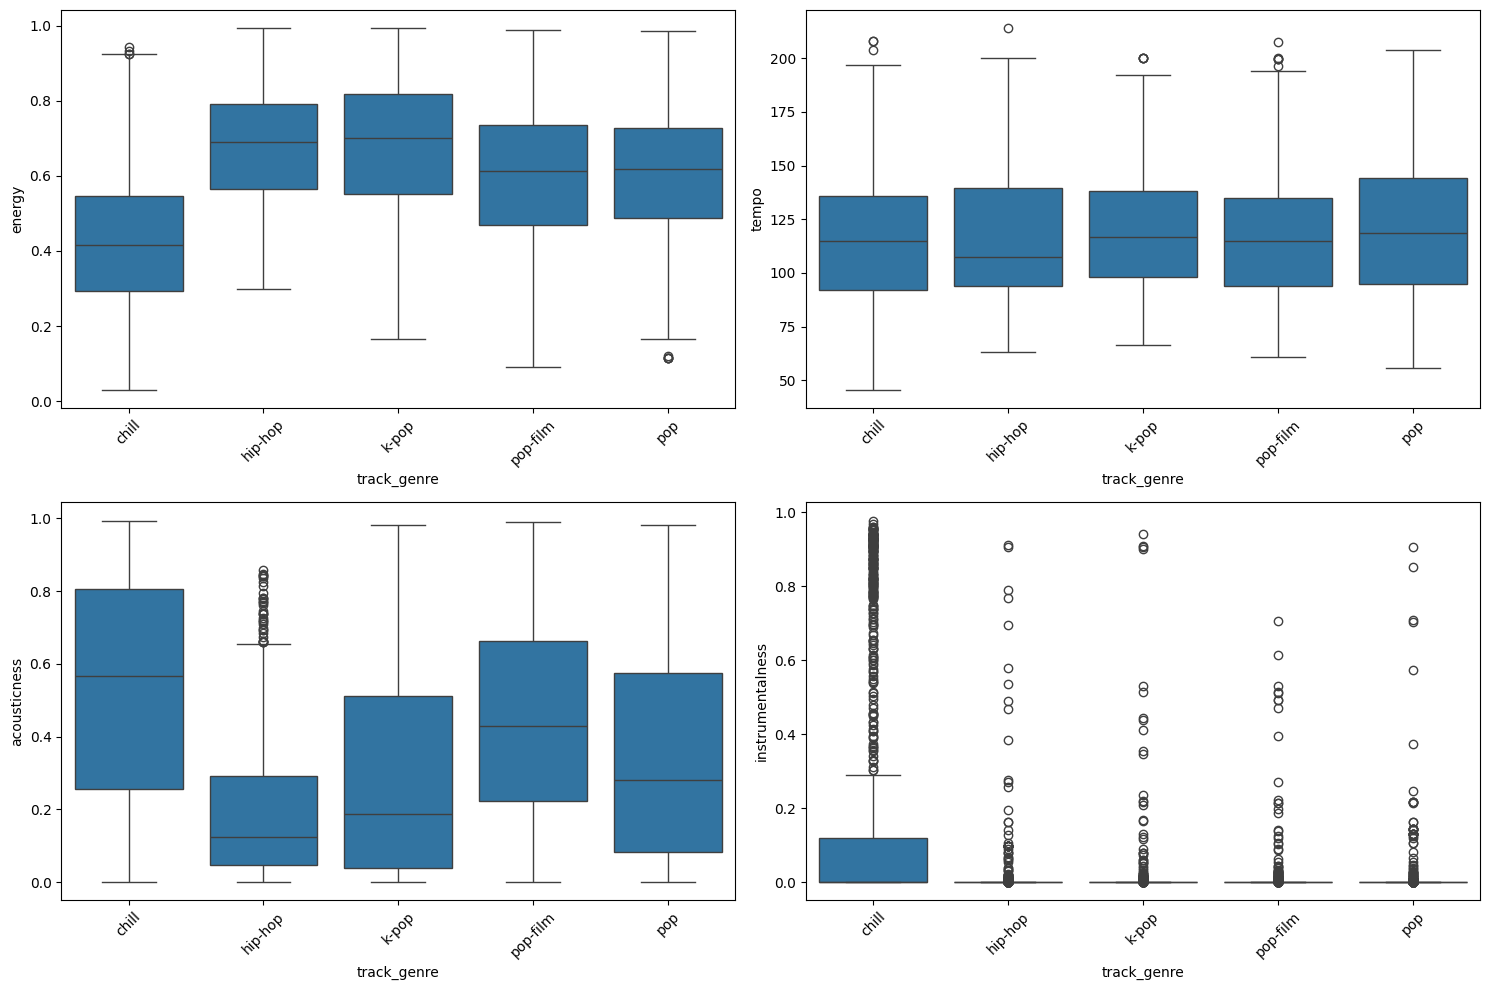

In [3]:
med_pop = spotify_df.groupby("track_genre")["popularity"].median()
med_pop_sorted = med_pop.sort_values(ascending=False)
top5_genres = med_pop_sorted.head(5).index.tolist()
spotify_most_pop = spotify_df[spotify_df["track_genre"].isin(top5_genres)]

features = ["energy", "tempo", "acousticness", "instrumentalness"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(
        data=spotify_most_pop,
        x="track_genre",
        y=feature,
        ax=ax
    )
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Below, the heatmap for the features are displayed. Because assigning songs to a genre is a multi-class classification problem and there are multiple genres a song could be, genre has been excluded from the heatmap. All other features to be used in the model have been displayed in the heatmap.

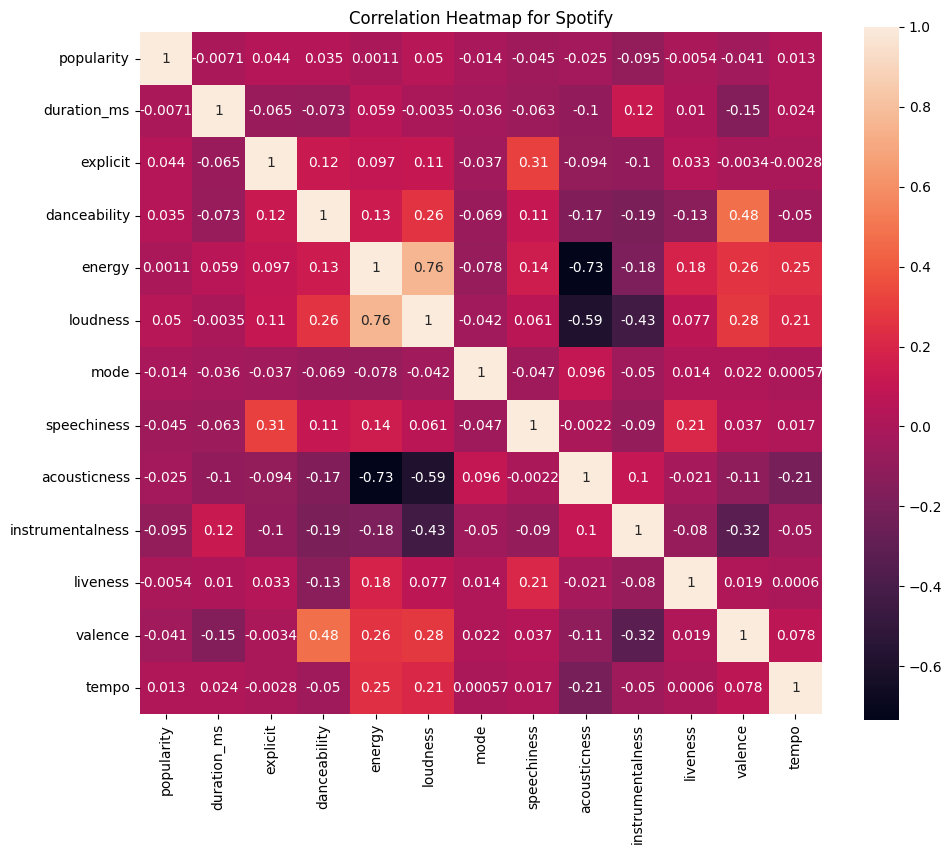

In [4]:
corr = spotify_reduced_df.corr()
f, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr,vmax=1,square=True, annot=True)
ax.set_title("Correlation Heatmap for Spotify")
ax.xaxis.tick_bottom()
ax.yaxis.tick_left()

The data needs to be split into training and testing data. This will be used to determine the accuracy of the model. It uses a 70:30 split with 70% of the original Spotify dataset being for testing and the remaining 30% being for testing. Also, the data needs to be standardized. For example, some of the data appears on a scale from 0-1, but other data, like the "tempo" column, is measured in beats-per-minute so it should be scaled down.

In [5]:
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.3,random_state=0)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

Here, the model is trained. Two models, Decision Tree and Random Forest, are examined. The models are fitted on the training data, then measured against the test data. By collecting the accuracy, precision, and recall for each model, the two models can be compared. 

In [6]:
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

accuracy, precision, recall = {}, {}, {}
for name, model in models.items():
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    accuracy[name] = metrics.accuracy_score(y_test, predictions)
    precision[name] = metrics.precision_score(y_test, predictions, average="weighted")
    recall[name] = metrics.recall_score(y_test, predictions, average="weighted")

c:\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [7]:
df_model = pd.DataFrame({'Accuracy': accuracy, 'Precision': precision, 'Recall':recall})
display(df_model)

,Accuracy,Precision,Recall
Decision Tree,0.216199,0.222103,0.216199
Random Forest,0.323743,0.315778,0.323743


**Results**

Overall, the models developed were not very accurate. Random Forest output a higher accuracy than Decision tree with an accuracy of 0.32. This was not terribly close to the majority of highly specialized models discussed in the literature. However, for traditional models, it's within range for expected accuracy. Also, the number of possible genres a song can be classified into is extremely high with over 100 genres. This naturally makes it harder to be accurate, especially with genres that are very similar. In the future, it would make sense to group genres into higher-level categories to improve the accuracy. However, this is still decent accuracy. There are 114 total genres, and if a genre were randomly assigned to a song, it would have a 0.89% chance of being the correct genre. As compared to the accuracy for the Random Forest Model, 32.4% chance to get the correct genre is much better. That said, it is still an interesting look into feature engineering. It was found that the addition of numeric features nearly always improved the model, despite the correlation analysis via the heatmap, even with features that might not seem like they would correlate to genre, such as "loudness," for example.

This research project showed that track features do correlate to track genre, and that they can be used to effectively assign genres to a song, but that it can be resource intensive, especially when attempting to classify into many different possible genres. Song classification remains an important research topic. It can be used for music recommendation systems, automatic playlist generation, and more. Music recommendation systems can be informed by machine learning models such as this to improve performance and efficiency.